In [1]:
import scanpy as sc
import omicverse as ov
ov.plot_set()

2024-11-23 20:17:58.744846: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-23 20:17:59.734761: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-23 20:18:00.912191: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-23 20:18:29.787675: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT



   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.6.9, Tutorials: https://omicverse.readthedocs.io/
Dependency error: (pydeseq2 0.4.11 (/mnt/home/zehuazeng/software/rsc/lib/python3.10/site-packages), Requirement.parse('pydeseq2<=0.4.0,>=0.3'))


In [2]:
fb=ov.pl.ForbiddenCity()
from IPython.display import HTML
HTML(fb.visual_color(loc_range=(0,384),
                    num_per_row=24))

人籁,青粲,翠缥,水龙吟,碧山,石发,菉竹,庭芜绿,葱倩,漆姑,翠微,芰荷,青青,翠虬,官绿,油绿,莓莓,螺青,春辰,麴尘,欧碧,苍葭,兰苕,青玉案
,,,,,,,,,,,,,,,,,,,,,,,
碧滋,瓷秘,筠雾,竹香子,鸣珂,琬琰,出岫,王刍,春碧,执大象,青圭,绿沈,风入松,荩篋,绞衣,素綦,苍筤,天缥,卵色,沧浪,葭菼,山岚,冰台,青古
,,,,,,,,,,,,,,,,,,,,,,,
醽醁,渌波,青楸,缥碧,翠涛,青梅,雀梅,苔古,蕉月,干山翠,翕赩,结绿,绿云,丹罽,黄丹,檎丹,银朱,洛神珠,珊瑚赫,朱孔阳,丹雘,水华朱,胭脂虫,朱樱
,,,,,,,,,,,,,,,,,,,,,,,
大繎,顺圣,爵头,麒麟竭,苕荣,扶光,十样锦,海天霞,驿刚,朱颜酡,赦霞,赦尾,缙云,小红,琼琚,岱赭,朱柿,艳炽,鹤顶红,赤缇,纁黄,棠梨,朱殷,石榴裙
,,,,,,,,,,,,,,,,,,,,,,,
朱草,赤灵,佛赤,綪茷,朱湛,丹秫,木兰,杨妃,盈盈,银红,粉米,桃夭,水红,夕岚,彤管,咸池,莲红,雌霓,縓缘,长春,渥赭,红䵂,紫梅,绛纱
,,,,,,,,,,,,,,,,,,,,,,,
茹藘,美人祭,唇脂,牙绯,鞓红,葡萄褐,蚩尤旗,紫矿,紫诰,苏方,霁红,蜜褐,福色,黪紫,龙膏烛,苏梅,琅环紫,胭脂水,紫茎屏风,红踯躅,胭脂紫,魏红,紫府,魏紫


In [3]:
adata=sc.read('data/GC_RNA/GC_ANNO.h5ad',compression='gzip')

In [4]:
dict(zip(
    adata.obs['patient'].tolist(),
    adata.obs['CancerStage'].tolist(),
))

{'GC05': 'T1',
 'GC06': 'T4',
 'GC07': 'T3',
 'GC10': 'T3',
 'GC09': 'T4',
 'GC02': 'T2',
 'GC03': 'T4',
 'GC04': 'T3',
 'GC01': 'T2',
 '10': 'Unknown',
 '11': 'Unknown',
 '12': 'Unknown',
 '14': 'Unknown',
 '15': 'Unknown',
 '16': 'Unknown',
 '17': 'Unknown',
 '3': 'Unknown',
 '4': 'Unknown',
 '5': 'Unknown',
 '8': 'Unknown',
 '9': 'Unknown',
 '6': 'Unknown',
 '7': 'Unknown',
 '18': 'Unknown',
 'EGC': 'T1',
 'IMW2': 'No',
 'IMS3': 'No',
 'IMS2': 'No',
 'CAG1': 'No',
 'CAG3': 'No',
 'NAG2': 'No',
 'NAG1': 'No',
 'IMW1': 'No',
 'IMS1': 'No',
 'NAG3': 'No',
 'IMS4': 'No',
 'CAG2': 'No'}

In [219]:
adata.obs['best_celltype']=adata.obs['best_celltype'].astype(str)
adata.obs.loc[adata.obs['best_celltype'].isin(['T cell','T helper cell']),'best_celltype']='T CD4+'
adata.obs.loc[adata.obs['best_celltype'].isin(['Cytotoxic t cell','Natural killer cell']),'best_celltype']='T CD8+'
adata.obs.loc[adata.obs['best_celltype'].isin(['Macrophage','Dendritic cell']),'best_celltype']='Myeloid'
adata.obs.loc[adata.obs['best_celltype'].isin(['Mucous neck cell']),'best_celltype']='Pyloric gland cell'


In [176]:
adata.obs['best_celltype'].cat.categories

Index(['B cell', 'Endothelial cell', 'Enterocyte', 'Enteroendocrine cell',
       'Fibroblast', 'Gastric Chief cell', 'Gastric foveolar cell',
       'Mast cell', 'Mucous neck cell', 'Myeloid', 'Pericyte', 'Plasma cell',
       'Pyloric gland cell', 'T CD4+', 'T CD8+', 'Tuft cell'],
      dtype='object')

In [4]:
color_dict={
    'B cell':fb.get_color(name='群青')['color_html'].values[0],
    'Plasma cell':fb.get_color(name='碧落')['color_html'].values[0],
    #'T cell':fb.get_color(name='麴尘')['color_html'].values[0],
    'T CD4+':fb.get_color(name='麴尘')['color_html'].values[0],
    'T CD8+':fb.get_color(name='庭芜绿')['color_html'].values[0],
    #'Natural killer cell':fb.get_color(name='缥碧')['color_html'].values[0],
    'Myeloid':fb.get_color(name='天水碧')['color_html'].values[0],
    'Mast cell':fb.get_color(name='醽醁')['color_html'].values[0],
    #'Dendritic cell':fb.get_color(name='井天')['color_html'].values[0],
    
    
    'Enterocyte':fb.get_color(name='苕荣')['color_html'].values[0],
    'Enteroendocrine cell':fb.get_color(name='杨妃')['color_html'].values[0],
    'Gastric Chief cell':fb.get_color(name='木兰')['color_html'].values[0],
    'Gastric foveolar cell':fb.get_color(name='莲红')['color_html'].values[0],
    'Pyloric gland cell':fb.get_color(name='渥赭')['color_html'].values[0],
    'Tuft cell':fb.get_color(name='唇脂')['color_html'].values[0],
    #'Mucous neck cell':fb.get_color(name='龙膏烛')['color_html'].values[0],
    'Endothelial cell':fb.get_color(name='水华朱')['color_html'].values[0],
    
    
    'Fibroblast':fb.get_color(name='紫蒲')['color_html'].values[0],
    'Pericyte':fb.get_color(name='木槿')['color_html'].values[0],

    'Unknown':fb.get_color(name='育阳染')['color_html'].values[0],
}

In [222]:
new_celltype_order=[]
for key in color_dict:
    if key in adata.obs['best_celltype'].cat.categories:
        new_celltype_order.append(key)
adata.obs['best_celltype']=adata.obs['best_celltype'].cat.reorder_categories(new_celltype_order)

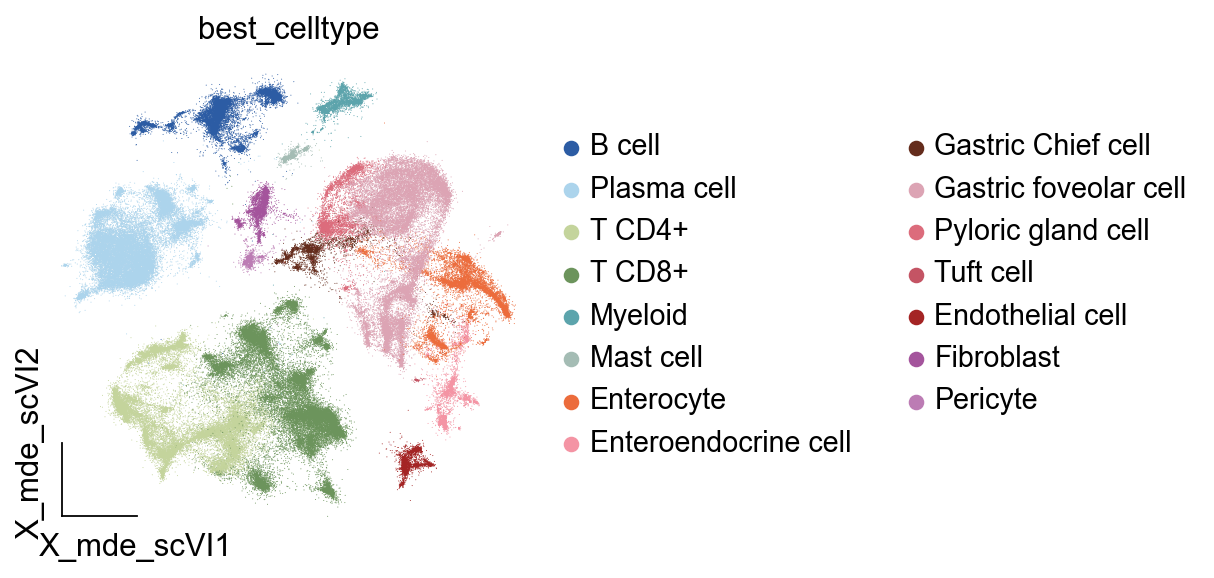

In [223]:
ov.pl.embedding(adata,
                basis='X_mde_scVI',
                color='best_celltype',
                palette=color_dict,
                frameon='small')

In [225]:
cell_abbreviations = {
    'B cell': 'B',
    'T CD8+': 'T_CD8',
    #'Dendritic cell': 'Dendritic',
    'Endothelial cell': 'Endothelial',
    'Enterocyte': 'Enterocyte',
    'Enteroendocrine cell': 'Enteroendo',
    'Fibroblast': 'Fibroblast',
    'Gastric Chief cell': 'GastricChief',
    'Gastric foveolar cell': 'GastricFoveolar',
    'Myeloid': 'Myeloid',
    'Mast cell': 'Mast',
    #'Mucous neck cell': 'MucousNeck',
    #'Natural killer cell': 'NK',
    'Pericyte': 'Pericyte',
    'Plasma cell': 'Plasma',
    'Pyloric gland cell': 'PyloricGland',
    'T CD4+': 'T_CD4',
    'Tuft cell': 'Tuft'
}

color_dict_abbreviations=dict(zip(
    [i for i in cell_abbreviations.values()],
    [color_dict[i] for i in cell_abbreviations.keys()]
))

adata.obs['cell_abbreviations']=adata.obs['best_celltype'].map(cell_abbreviations)

<AxesSubplot: xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>

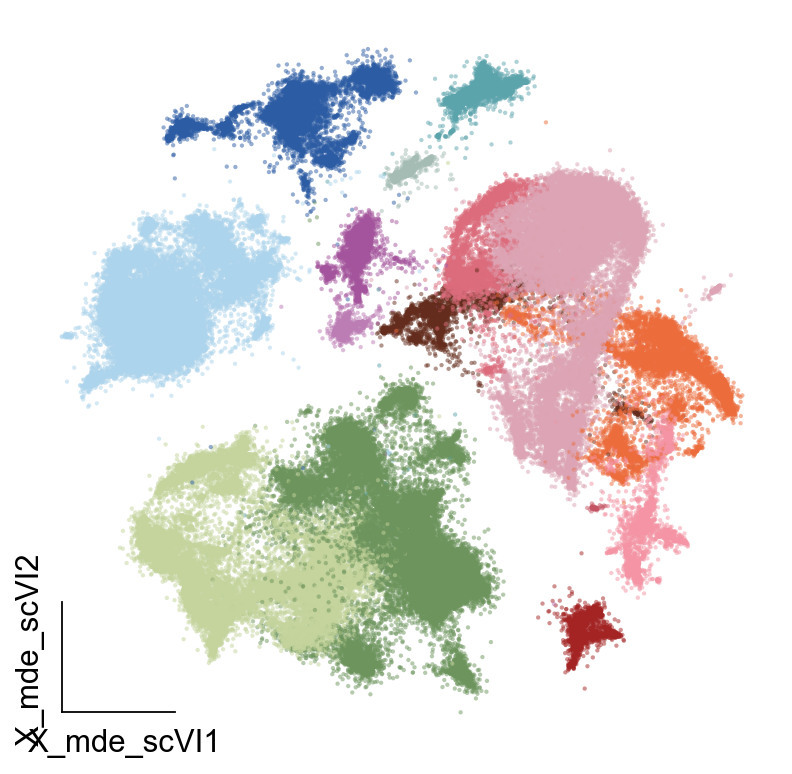

In [226]:
from matplotlib import patheffects
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,6))

ov.pl.embedding(adata,
                  basis='X_mde_scVI',
                  color=['best_celltype'],
                    size=15,
                title='',alpha=0.5,
                   show=False, legend_loc=None, add_outline=False, 
                   frameon='small',legend_fontoutline=2,ax=ax
                 )




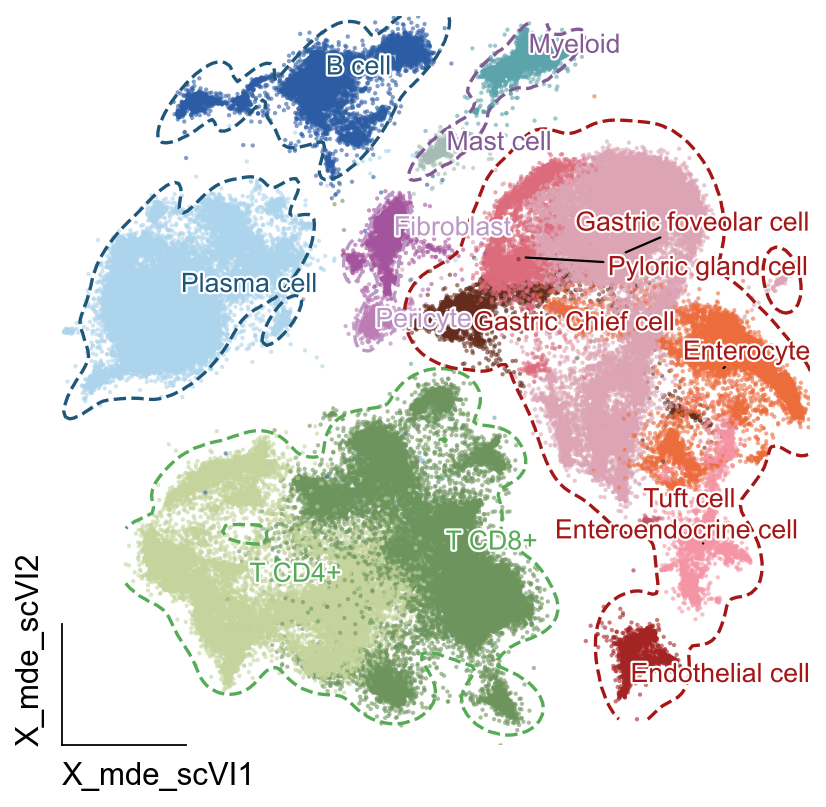

In [227]:
from matplotlib import patheffects
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,6))

ov.pl.embedding(adata,
                  basis='X_mde_scVI',
                  color=['best_celltype'],
                    size=15,title='',alpha=0.6,
                   show=False, legend_loc=None, add_outline=False, 
                   frameon='small',legend_fontoutline=2,ax=ax
                 )



c1=['B cell','Plasma cell']
ov.pl.contour(ax=ax,adata=adata,groupby='best_celltype',clusters=c1,
       basis='X_mde_scVI',contour_threshold=0.05,colors=ov.pl.blue_color[1],
        linestyles='dashed',)

c2=['T CD4+','T CD8+']
ov.pl.contour(ax=ax,adata=adata,groupby='best_celltype',clusters=c2,
       basis='X_mde_scVI',contour_threshold=0.05,colors=ov.pl.green_color[2],
        linestyles='dashed',)

c3=['Enterocyte','Enteroendocrine cell', 'Gastric Chief cell','Gastric foveolar cell',
    'Pyloric gland cell','Tuft cell','Mucous neck cell','Endothelial cell']
ov.pl.contour(ax=ax,adata=adata,groupby='best_celltype',clusters=c3,
       basis='X_mde_scVI',contour_threshold=0.05,colors='#a51616',
        linestyles='dashed',)

c4=['Myeloid', 'Mast cell',]
ov.pl.contour(ax=ax,adata=adata,groupby='best_celltype',clusters=c4,
       basis='X_mde_scVI',contour_threshold=0.05,colors=ov.pl.purple_color[1],
        linestyles='dashed',)

c5=['Fibroblast','Pericyte',]
ov.pl.contour(ax=ax,adata=adata,groupby='best_celltype',clusters=c5,
       basis='X_mde_scVI',contour_threshold=0.05,colors=ov.pl.purple_color[2],
        linestyles='dashed',)




ov.pl.embedding_adjust(
    adata,
    groupby='best_celltype',
    exclude=set(c2+c3+c4+c5),  
    basis='X_mde_scVI',
    ax=ax,
    adjust_kwargs=dict(arrowprops=dict(arrowstyle='-', color='black')),
    text_kwargs=dict(fontsize=12 ,weight='normal',color=ov.pl.blue_color[1],
                     path_effects=[patheffects.withStroke(linewidth=2, foreground='w')] ),
)

ov.pl.embedding_adjust(
    adata,
    groupby='best_celltype',
    exclude=set(c1+c3+c4+c5),  
    basis='X_mde_scVI',
    ax=ax,
    adjust_kwargs=dict(arrowprops=dict(arrowstyle='-', color='black')),
    text_kwargs=dict(fontsize=12 ,weight='normal',color=ov.pl.green_color[2],
                     path_effects=[patheffects.withStroke(linewidth=2, foreground='w')] ),
)

ov.pl.embedding_adjust(
    adata,
    groupby='best_celltype',
    exclude=set(c1+c2+c4+c5),  
    basis='X_mde_scVI',
    ax=ax,
    adjust_kwargs=dict(arrowprops=dict(arrowstyle='-', color='black')),
    text_kwargs=dict(fontsize=12 ,weight='normal',color='#a51616',
                     path_effects=[patheffects.withStroke(linewidth=2, foreground='w')] ),
)

ov.pl.embedding_adjust(
    adata,
    groupby='best_celltype',
    exclude=set(c1+c2+c3+c5),  
    basis='X_mde_scVI',
    ax=ax,
    adjust_kwargs=dict(arrowprops=dict(arrowstyle='-', color='black')),
    text_kwargs=dict(fontsize=12 ,weight='normal',color=ov.pl.purple_color[1],
                     path_effects=[patheffects.withStroke(linewidth=2, foreground='w')] ),
)

ov.pl.embedding_adjust(
    adata,
    groupby='best_celltype',
    exclude=set(c1+c2+c3+c4),  
    basis='X_mde_scVI',
    ax=ax,
    adjust_kwargs=dict(arrowprops=dict(arrowstyle='-', color='black')),
    text_kwargs=dict(fontsize=12 ,weight='normal',color=ov.pl.purple_color[2],
                     path_effects=[patheffects.withStroke(linewidth=2, foreground='w')] ),
)


fig.savefig('figures/qc/umap-ct_minor-66.png',dpi=300,bbox_inches='tight')
#fig.savefig('pdf/qc/umap-ct_minor-66.pdf',dpi=300,bbox_inches='tight')


In [186]:
adata.write('data/GC_RNA/GC_ANNO.h5ad',compression='gzip')

In [39]:
import numpy as np
adata.obs['log2umi']=np.log2(adata.obs['nUMIs'].values)
adata.obs['log2counts']=np.log2(adata.obs['detected_genes'].values)
adata.obs['pct_counts_mt']=adata.obs['mito_perc'].values*100

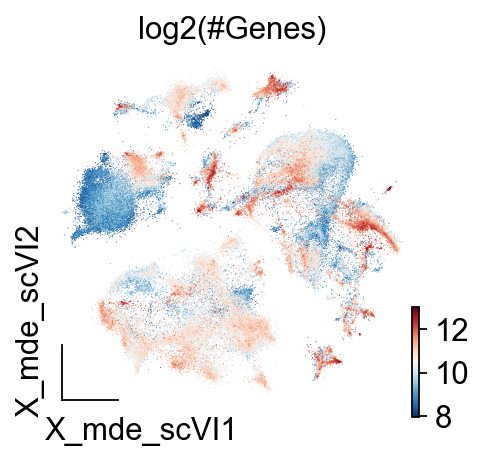

In [40]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(3,3))
ov.utils.embedding(
    adata,
    basis="X_mde_scVI",
    color=['log2counts'],
    title='log2(#Genes)',
    frameon='small',
    #ncols=1,
    #palette=Pyomic.utils.pyomic_palette(),
    #legend_loc='on data',
    #legend_fontsize=12,
    #vmax=15,
    ax=ax,
    show=False
    #add_outline=True
    #legend_fontweight='normal'
)
fig.savefig('figures/qc/umap-log2counts-33.png',dpi=300,bbox_inches='tight')
#fig.savefig('pdf/qc/umap-log2counts-33.pdf',dpi=300,bbox_inches='tight')


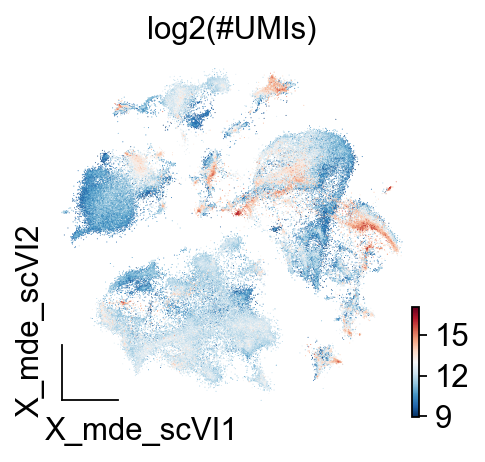

In [41]:

fig, ax = plt.subplots(figsize=(3,3))
ov.utils.embedding(
    adata,
    basis="X_mde_scVI",
    color=['log2umi'],
    title='log2(#UMIs)',
    frameon='small',
    #cmap=cmap1,
    #palette=Pyomic.utils.pyomic_palette(),
    #legend_loc='on data',
    #legend_fontsize=12,
    #vmax=15,
    ax=ax,
    show=False
    #add_outline=True
    #legend_fontweight='normal'
)
fig.savefig('figures/qc/umap-log2umis-33.png',dpi=300,bbox_inches='tight')
#fig.savefig('pdf/qc/umap-log2umis-33.pdf',dpi=300,bbox_inches='tight')


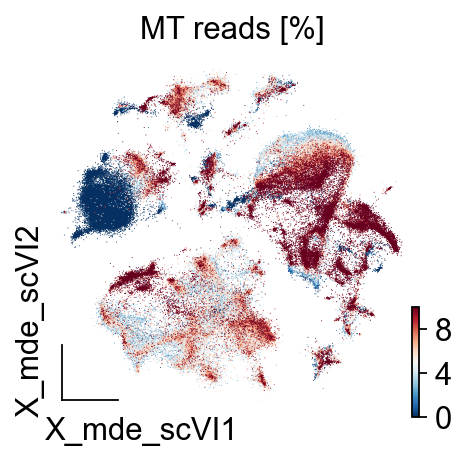

In [42]:
fig, ax = plt.subplots(figsize=(3,3))
ov.utils.embedding(
    adata,
    basis="X_mde_scVI",
    color=['pct_counts_mt'],
    title='MT reads [%]',
    frameon='small',
    #ncols=1,
    #palette=Pyomic.utils.pyomic_palette(),
    #legend_loc='on data',
    #legend_fontsize=12,
    vmax=10,
    ax=ax,
    show=False
    
    #add_outline=True
    #legend_fontweight='normal'
)
fig.savefig('figures/qc/umap-mt-33.png',dpi=300,bbox_inches='tight')
#fig.savefig('pdf/qc/umap-mt-33.pdf',dpi=300,bbox_inches='tight')


In [43]:
adata_raw=adata.raw.to_adata()

In [44]:
ov.pp.score_genes_cell_cycle(adata_raw,s_genes=None, g2m_genes=None,species='human')

#adata_raw.var['mt']=False
#adata_raw.var.loc[list(set(adata_raw.var_names) & set(mito_genes1)),'mt']=True
#adata_raw.obs['mito_perc'] = adata_raw[:, adata_raw.var["mt"]].X.toarray().sum(axis=1) / adata_raw.obs['nUMIs'].values

calculating cell cycle phase
computing score 'S_score'
    finished: added
    'S_score', score of gene set (adata.obs).
    728 total control genes are used. (0:00:03)
computing score 'G2M_score'
    finished: added
    'G2M_score', score of gene set (adata.obs).
    684 total control genes are used. (0:00:03)
-->     'phase', cell cycle phase (adata.obs)


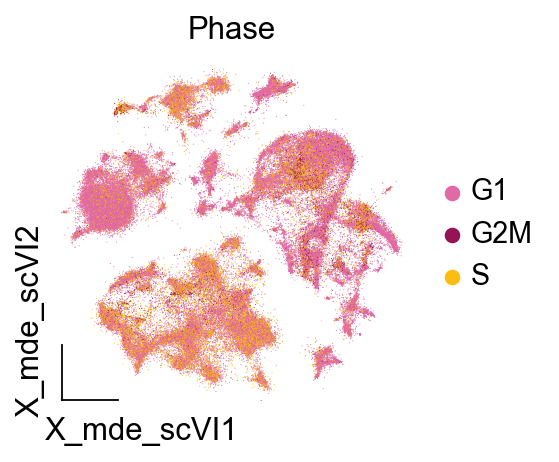

In [45]:
fig, ax = plt.subplots(figsize=(3,3))
ov.utils.embedding(
    adata_raw,
    basis="X_mde_scVI",
    color=['phase'],
    title='Phase',
    frameon='small',
    #ncols=1,
    palette=ov.utils.pyomic_palette()[14:],
    #legend_loc='on data',
    #legend_fontsize=12,
    ax=ax,
    show=False
    #add_outline=True
    #legend_fontweight='normal'
)
fig.savefig('figures/qc/umap-phase-33.png',dpi=300,bbox_inches='tight')
#fig.savefig('pdf/qc/umap-phase-33.pdf',dpi=300,bbox_inches='tight')


In [47]:
adata

AnnData object with n_obs × n_vars = 148350 × 3000
    obs: 'patient', 'CancerType', 'CancerStage', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'n_genes', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', '_scvi_batch', '_scvi_labels', 'leiden', 'celltype_gbi', 'celltype_gpt', 'best_clusters', 'gpt_celltype_0', 'gpt_celltype_1', 'gpt_celltype_2', 'gpt_celltype_3', 'gpt_celltype_4', 'best_celltype', 'Major_celltype', 'Minor_celltype', 'C_scANVI', 'cell_type_from_scMulan', 'cell_type_from_mulan_smoothing', 'smoothing_score', 'cell_abbreviations', 'log2umi', 'log2counts', 'pct_counts_mt'
    var: 'mt', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_features'
    uns: 'CancerStage_colors', 'CancerType_colors', 'Smoothing', 'bench_best_res', 'best_celltype_colors', 'cell_type_from_mulan_smoothing_colors', 

NameError: name 'adata_raw' is not defined

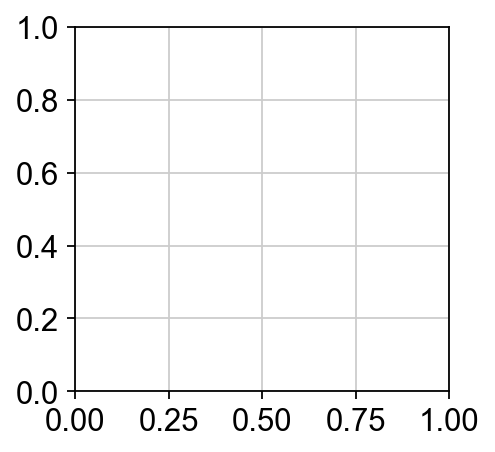

In [13]:
import colorcet
fig, ax = plt.subplots(figsize=(3,3))
ov.utils.embedding(
    adata_raw,
    basis="X_mde_scVI",
    color=['patient'],
    title='Patient',
    frameon='small',
    #ncols=1,
    palette=colorcet.glasbey_bw_minc_20_maxl_70,
    #legend_loc='on data',
    #legend_fontsize=12,
    ax=ax,
    show=False
    #add_outline=True
    #legend_fontweight='normal'
)
fig.savefig('figures/qc/umap-sample-33.png',dpi=300,bbox_inches='tight')

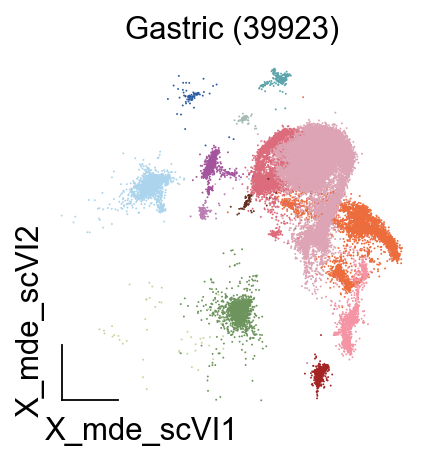

In [11]:
import colorcet
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(3,3))
ad1=adata[adata.obs['CancerStage'].isin(['No'])]
ov.utils.embedding(
    ad1,
    basis="X_mde_scVI",
    color=['best_celltype'],
    title=f'Gastric ({ad1.shape[0]})',
    frameon='small',
    #ncols=1,
    #palette=colorcet.glasbey_bw_minc_20_maxl_70,
    legend_loc=False,
    #legend_fontsize=12,
    ax=ax,
    show=False
    #add_outline=True
    #legend_fontweight='normal'
)
fig.savefig('figures/qc/umap-gas-sample-33.png',dpi=300,bbox_inches='tight')

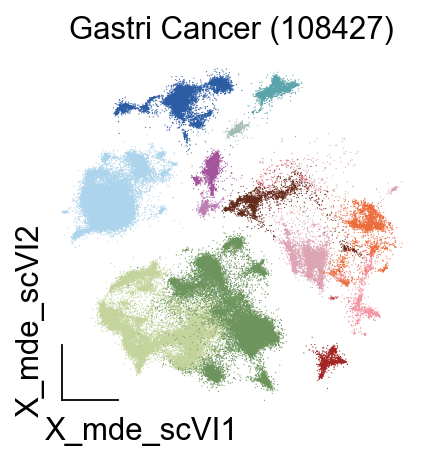

In [12]:
import colorcet
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(3,3))
ad1=adata[~adata.obs['CancerStage'].isin(['No'])]
ov.utils.embedding(
    ad1,
    basis="X_mde_scVI",
    color=['best_celltype'],
    title=f'Gastri Cancer ({ad1.shape[0]})',
    frameon='small',
    #ncols=1,
    #palette=colorcet.glasbey_bw_minc_20_maxl_70,
    legend_loc=False,
    #legend_fontsize=12,
    ax=ax,
    show=False
    #add_outline=True
    #legend_fontweight='normal'
)
fig.savefig('figures/qc/umap-gc-sample-33.png',dpi=300,bbox_inches='tight')

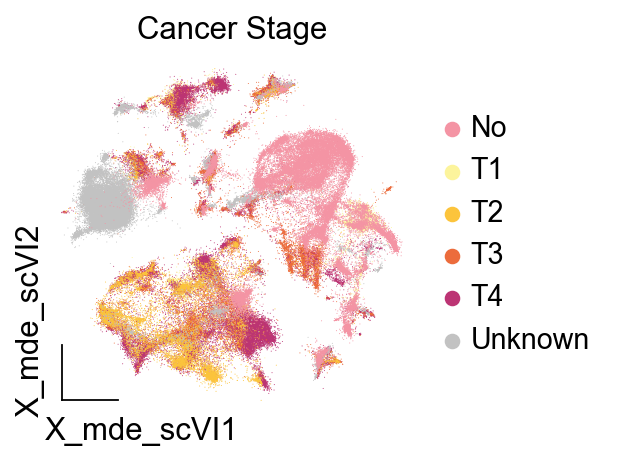

In [55]:
fig, ax = plt.subplots(figsize=(3,3))
ov.utils.embedding(
    adata,
    basis="X_mde_scVI",
    color=['CancerStage'],
    title='Cancer Stage',
    frameon='small',
    #ncols=1,
    palette=[
             fb.get_color(name='杨妃')['color_html'].values[0],
             fb.get_color(name='黄白游')['color_html'].values[0],
             fb.get_color(name='栀子')['color_html'].values[0],
             fb.get_color(name='苕荣')['color_html'].values[0],#
             fb.get_color(name='红踯躅')['color_html'].values[0],
            '#c2c2c2',],
    #legend_loc='on data',
    #legend_fontsize=12,
    ax=ax,
    show=False
    #add_outline=True
    #legend_fontweight='normal'
)
fig.savefig('figures/qc/umap-CancerStage-33.png',dpi=300,bbox_inches='tight')

In [15]:
patient_type=dict(zip(
    adata.obs['patient'].tolist(),
    adata.obs['CancerStage'].tolist()
))

In [17]:
cancerstage_color=dict(zip(
    adata.obs['CancerStage'].cat.categories,
    adata.uns['CancerStage_colors']
))

In [18]:
patient_color=dict(zip(
    patient_type.keys(),
    [cancerstage_color[patient_type[i]] for i in patient_type.keys()]
))

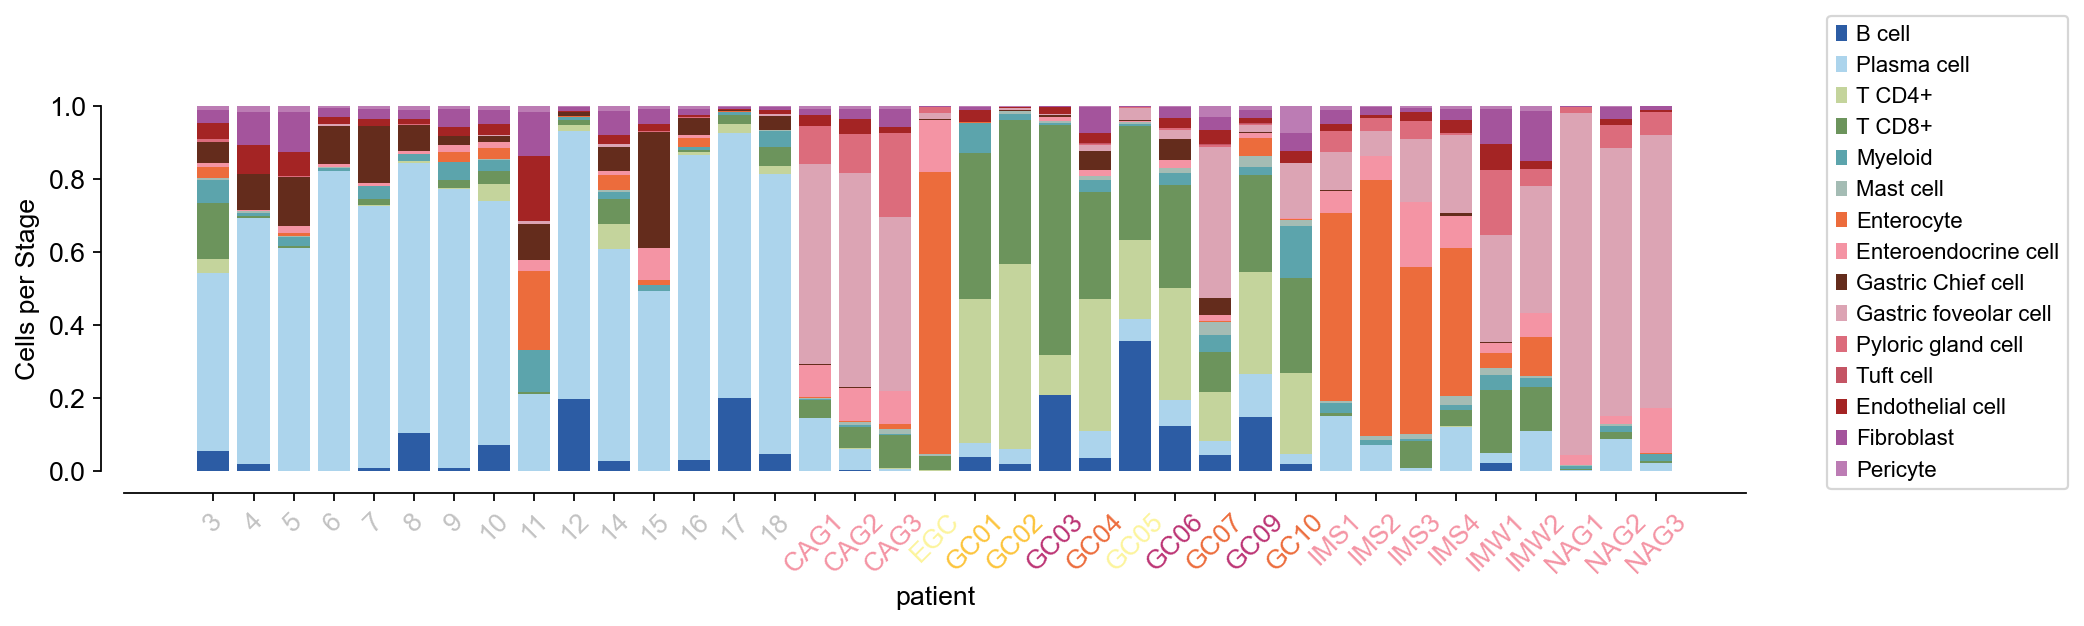

In [20]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize = (13,3))
ov.pl.cellproportion(adata=adata,celltype_clusters='best_celltype',
                    groupby='patient',legend=True,ax=ax)
plt.xticks(fontsize=12,rotation=45)
plt.yticks(fontsize=12)


for label in ax.get_xticklabels():
    label_text = label.get_text()
    if label_text in patient_color:
        label.set_color(patient_color[label_text])

fig.savefig('figures/qc/prop-sample-ct-13-3.png',dpi=300,bbox_inches='tight')

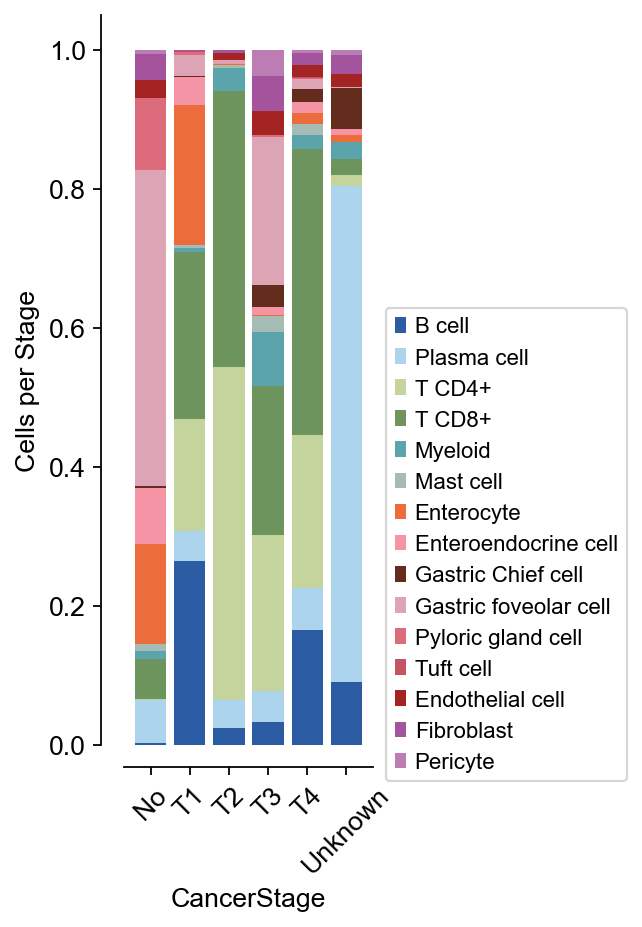

In [229]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize = (2,6))
ov.pl.cellproportion(adata=adata,celltype_clusters='best_celltype',
                    groupby='CancerStage',legend=True,ax=ax)
plt.xticks(fontsize=12,rotation=45)
plt.yticks(fontsize=12)
fig.savefig('figures/qc/prop-CancerStage-ct-26.png',dpi=300,bbox_inches='tight')

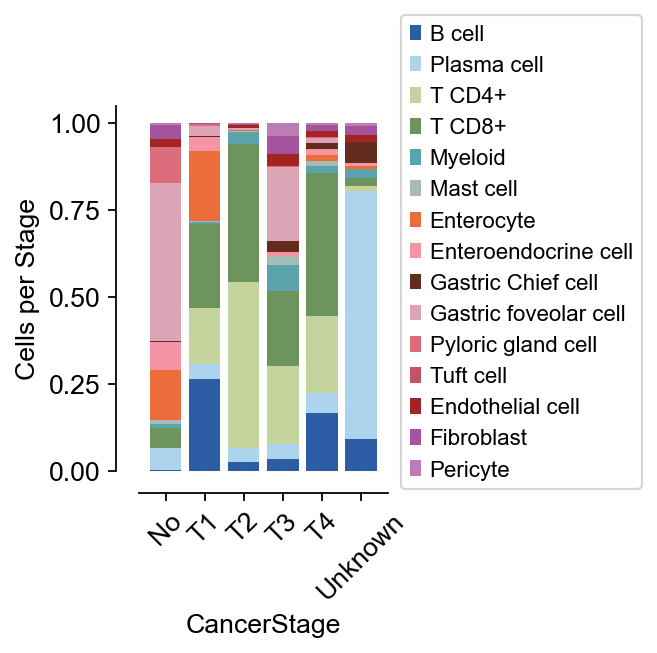

In [230]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize = (2,3))
ov.pl.cellproportion(adata=adata,celltype_clusters='best_celltype',
                    groupby='CancerStage',legend=True,ax=ax)
plt.xticks(fontsize=12,rotation=45)
plt.yticks(fontsize=12)
fig.savefig('figures/qc/prop-CancerStage-ct-23.png',dpi=300,bbox_inches='tight')

best_celltype_colors


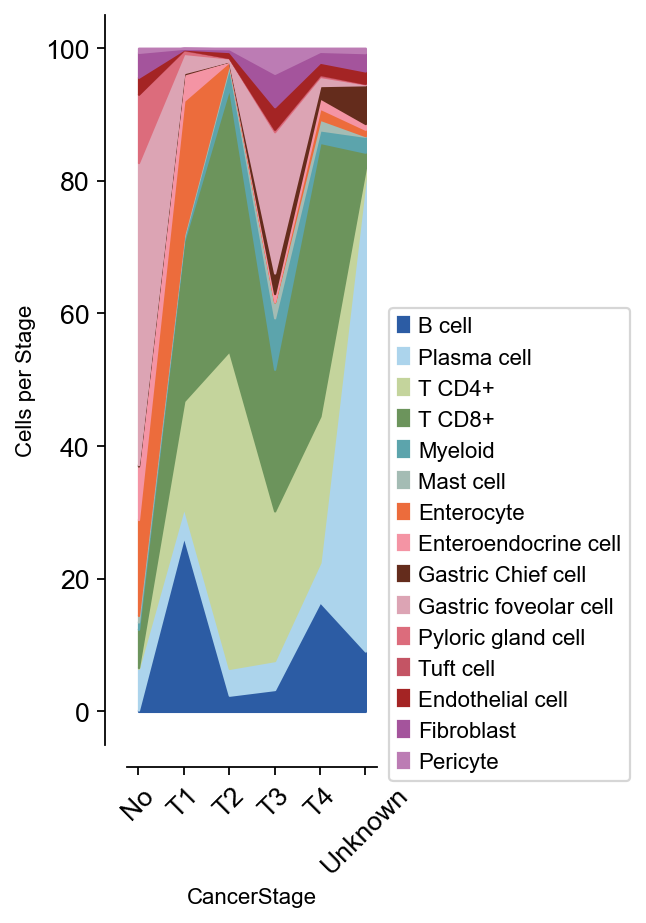

In [231]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize = (2,6))
ov.pl.cellstackarea(adata=adata,celltype_clusters='best_celltype',
                    labels_fontsize=10,
                    groupby='CancerStage',legend=True,ax=ax,legend_awargs={})
plt.xticks(fontsize=12,rotation=45)
plt.yticks(fontsize=12)
fig.savefig('figures/qc/cellstackarea-CancerStage-ct-26.png',dpi=300,bbox_inches='tight')

best_celltype_colors


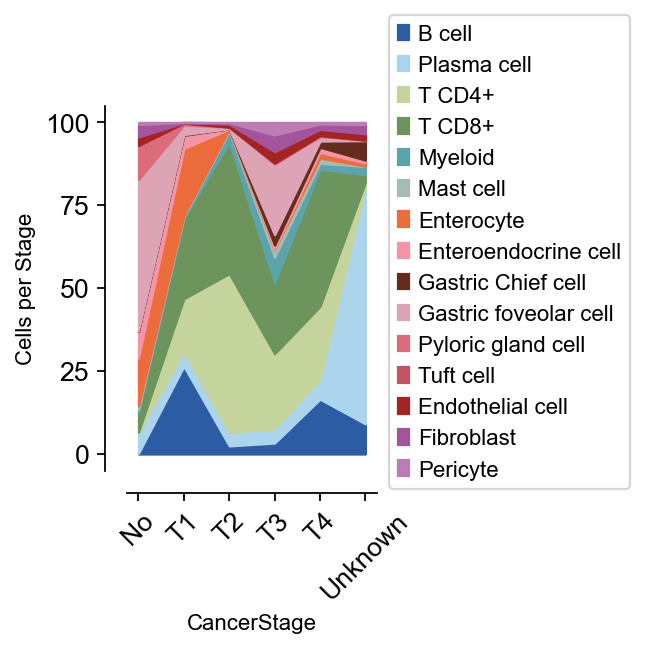

In [232]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize = (2,3))
ov.pl.cellstackarea(adata=adata,celltype_clusters='best_celltype',
                    labels_fontsize=10,
                    groupby='CancerStage',legend=True,ax=ax,legend_awargs={})
plt.xticks(fontsize=12,rotation=45)
plt.yticks(fontsize=12)
fig.savefig('figures/qc/cellstackarea-CancerStage-ct-23.png',dpi=300,bbox_inches='tight')

In [21]:
adata_sub=adata[adata.obs['CancerStage'].isin(['No','T1','T2'])]
adata_sub

View of AnnData object with n_obs × n_vars = 66467 × 3000
    obs: 'patient', 'CancerType', 'CancerStage', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'n_genes', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', '_scvi_batch', '_scvi_labels', 'leiden', 'celltype_gbi', 'celltype_gpt', 'best_clusters', 'gpt_celltype_0', 'gpt_celltype_1', 'gpt_celltype_2', 'gpt_celltype_3', 'gpt_celltype_4', 'best_celltype', 'Major_celltype', 'Minor_celltype', 'C_scANVI', 'cell_type_from_scMulan', 'cell_type_from_mulan_smoothing', 'smoothing_score', 'cell_abbreviations', 'log2umi', 'log2counts', 'pct_counts_mt'
    var: 'mt', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_features'
    uns: 'CancerStage_colors', 'CancerType_colors', 'Smoothing', 'bench_best_res', 'best_celltype_colors', 'cell_type_from_mulan_smoothing_co

In [22]:
import pandas as pd
res=pd.DataFrame()
ct=adata_sub.obs['best_celltype'].cat.categories

res['Healthy']=adata_sub.obs.loc[adata_sub.obs['CancerStage'].isin(['No'])]['best_celltype'].value_counts().loc[ct]
res['T1']=adata_sub.obs.loc[adata_sub.obs['CancerStage'].isin(['T1'])]['best_celltype'].value_counts().loc[ct]
res['T2']=adata_sub.obs.loc[adata_sub.obs['CancerStage'].isin(['T2'])]['best_celltype'].value_counts().loc[ct]
res

,Healthy,T1,T2
B cell,80,2701,399
Plasma cell,2516,443,661
T CD4+,47,1634,7828
T CD8+,2297,2461,6489
Myeloid,438,56,531
Mast cell,399,44,86
Enterocyte,5769,2059,22
Enteroendocrine cell,3225,407,9
Gastric Chief cell,76,20,1
Gastric foveolar cell,18189,297,73


In [23]:
roe=ov.utils.roe(adata_sub,sample_key='CancerStage',cell_type_key='best_celltype')

chi2: 58646.593152830865, dof: 28, pvalue: 0.0
Some expected frequencies are less than 5, it is suggested to use other statistical methods, such as Fisher's exact test


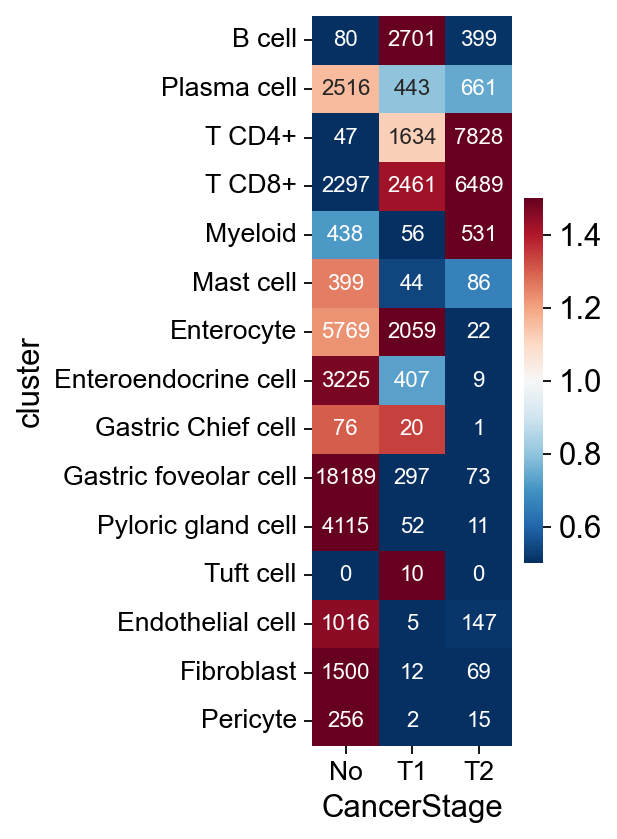

In [237]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(2,6))

transformed_roe = roe.copy()
transformed_roe = transformed_roe.applymap(
    lambda x: '+++' if x >= 2 else ('++' if x >= 1.5 else ('+' if x >= 1 else '+/-')))

sns.heatmap(roe, annot=res, cmap='RdBu_r', fmt='', 
            cbar=True, ax=ax,vmin=0.5,vmax=1.5,cbar_kws={'shrink':0.5},
           annot_kws={"fontsize":10})
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
fig.savefig(f'figures/qc/prop-num.png',dpi=300,bbox_inches='tight')

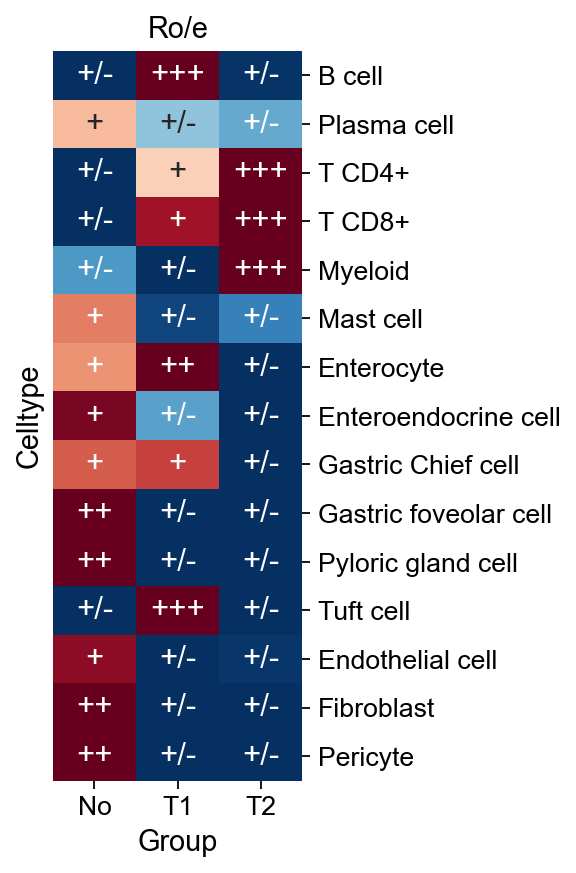

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(2,6))

transformed_roe = roe.copy()
transformed_roe = transformed_roe.applymap(
    lambda x: '+++' if x >= 2 else ('++' if x >= 1.5 else ('+' if x >= 1 else '+/-')))

sns.heatmap(roe, annot=transformed_roe, cmap='RdBu_r', fmt='', 
            #cbar=True, 
            ax=ax,vmin=0.5,vmax=1.5,cbar_kws={'shrink':0.5},
           cbar=False)


plt.xlabel('Group',fontsize=13)
plt.ylabel(f'Celltype',fontsize=13)
plt.title('Ro/e',fontsize=13)

# 设置y轴和x轴的位置
ax.yaxis.set_ticks_position('right')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12,rotation=360)
#ax.yaxis.set_label_position('right')

fig.savefig(f'figures/qc/prop-roe-26.png',dpi=300,bbox_inches='tight')

In [32]:
sns.heatmap?

Signature:
sns.heatmap(
    data,
    *,
    vmin=None,
    vmax=None,
    cmap=None,
    center=None,
    robust=False,
    annot=None,
    fmt='.2g',
    annot_kws=None,
    linewidths=0,
    linecolor='white',
    cbar=True,
    cbar_kws=None,
    cbar_ax=None,
    square=False,
    xticklabels='auto',
    yticklabels='auto',
    mask=None,
    ax=None,
    **kwargs,
)
Docstring:
Plot rectangular data as a color-encoded matrix.

This is an Axes-level function and will draw the heatmap into the
currently-active Axes if none is provided to the ``ax`` argument.  Part of
this Axes space will be taken and used to plot a colormap, unless ``cbar``
is False or a separate Axes is provided to ``cbar_ax``.

Parameters
----------
data : rectangular dataset
    2D dataset that can be coerced into an ndarray. If a Pandas DataFrame
    is provided, the index/column information will be used to label the
    columns and rows.
vmin, vmax : floats, optional
    Values to anchor the colormap, otherwise

In [ ]:
all_markers=ov.single.get_celltype_marker(adata,clustertype='best_celltype',rank=False,
                                          key='rank_genes_groups',
                                          foldchange=2,topgenenumber=5)
all_markers

In [239]:
all_markers

{'B cell': ['HLA-DRA', 'CD74', 'MS4A1', 'CD37', 'HLA-DPB1'],
 'Cytotoxic t cell': ['CCL5', 'CD8A', 'CD3E', 'IL32', 'NKG7'],
 'Dendritic cell': ['GPR183', 'PLD4', 'IL3RA', 'IRF7', 'NR4A3'],
 'Endothelial cell': ['SPARCL1', 'IFITM3', 'CRIP2', 'IGFBP7', 'RAMP2'],
 'Enterocyte': ['CLDN4', 'REG4', 'LGALS4', 'KRT8', 'KRT18'],
 'Enteroendocrine cell': ['MDK', 'PCSK1N', 'EPCAM', 'SCG5', 'MS4A8'],
 'Fibroblast': ['DCN', 'CALD1', 'COL6A2', 'RARRES2', 'MFAP4'],
 'Gastric Chief cell': ['CYSTM1', 'PGC', 'LIPF', 'CST3', 'MT1E'],
 'Gastric foveolar cell': ['MUC5AC', 'S100P', 'TFF1', 'TFF2', 'CYSTM1'],
 'Macrophage': ['TYROBP', 'FCER1G', 'HLA-DRA', 'AIF1', 'FTH1'],
 'Mast cell': ['TPSAB1', 'CPA3', 'FTH1', 'HPGDS', 'LMNA'],
 'Mucous neck cell': ['GAST', 'TFF2', 'LYZ', 'GKN1', 'MT-ND4'],
 'Natural killer cell': ['CCL5', 'KLRD1', 'NKG7', 'CD7', 'CST7'],
 'Pericyte': ['CALD1', 'MYL9', 'IGFBP7', 'ACTA2', 'TPM2'],
 'Plasma cell': ['SSR4', 'MZB1', 'DERL3', 'SPCS1', 'SEC61B'],
 'Pyloric gland cell': ['LYZ', '

[<AxesSubplot: title={'center': 'POU2F3'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>,
 <AxesSubplot: title={'center': 'best_celltype'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>]

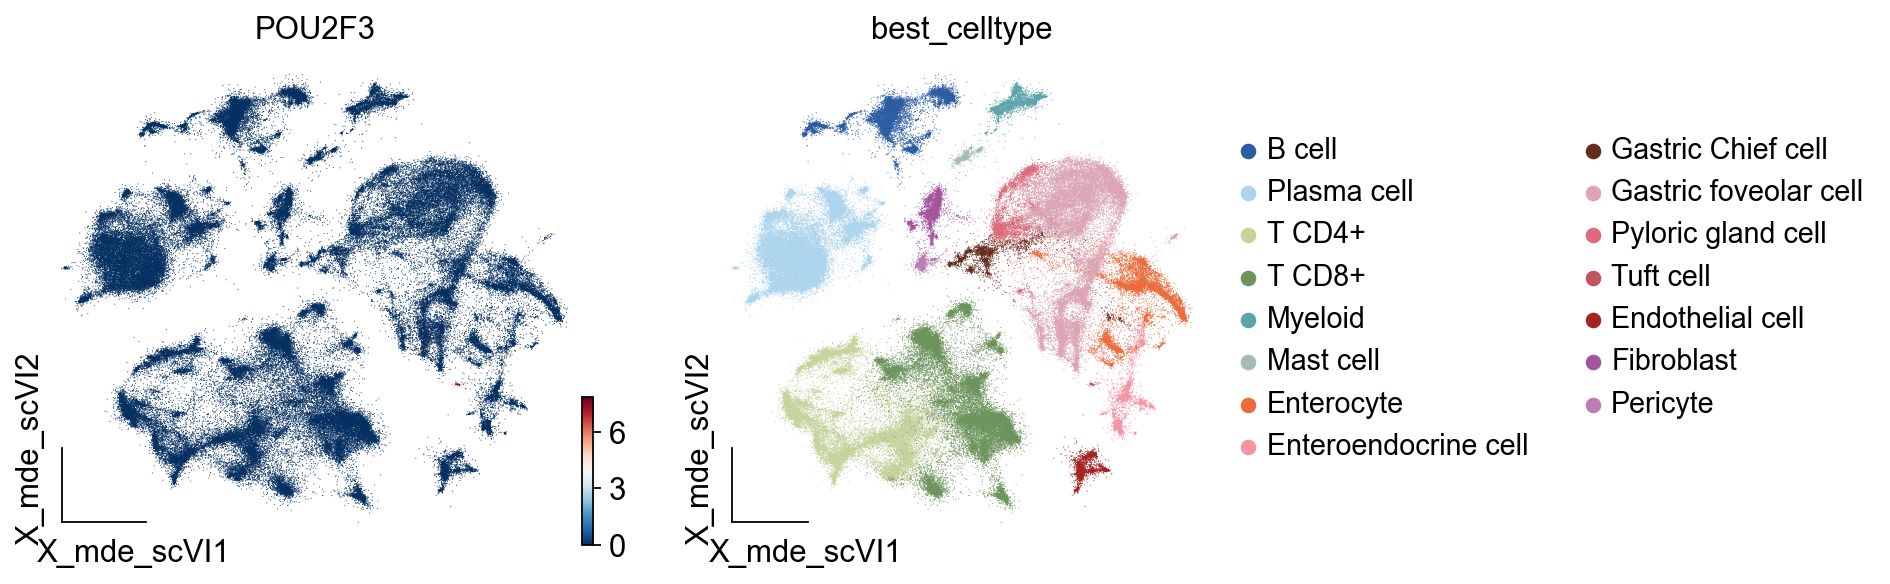

In [247]:
gene='POU2F3'

#fig, ax = plt.subplots(figsize=(3,3))
ov.utils.embedding(
    adata,
    basis="X_mde_scVI",
    color=[gene,'best_celltype'],
    #title='Patient',
    frameon='small',
    ncols=2,
    #palette=colorcet.glasbey_bw_minc_20_maxl_70,
    #legend_loc='on data',
    #legend_fontsize=12,
    #ax=ax,
    show=False
    #add_outline=True
    #legend_fontweight='normal'
)

Storing dendrogram info using `.uns['dendrogram_best_celltype']`


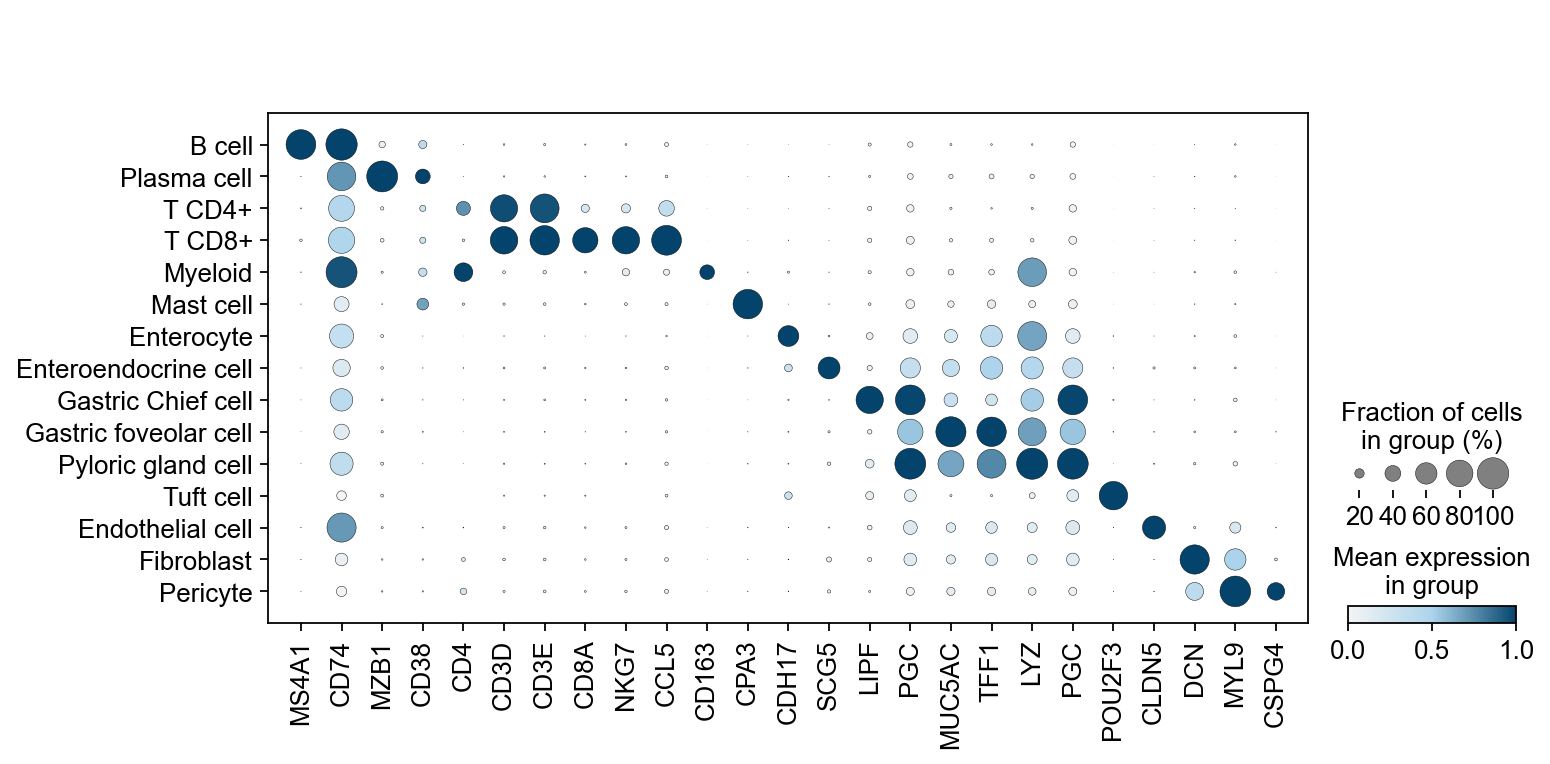

In [274]:
markers ={
    'B cell':['MS4A1','CD74'],
    'Plasma cell':['MZB1','CD38'],
    'T CD4+':['CD4','CD3D','CD3E'],
    'T CD8+':['CD8A','NKG7','CCL5'],
    'Myeloid':['CD163'],
    'Mast cell':['CPA3'],
    
    
    'Enterocyte':['CDH17'],
    'Enteroendocrine cell':['SCG5'],
    'Gastric Chief cell':['LIPF','PGC', ],
    'Gastric foveolar cell':['MUC5AC','TFF1'],
    'Pyloric gland cell':['LYZ', 'PGC',],
    'Tuft cell':['POU2F3'],
    'Endothelial cell':['CLDN5'],
    
    
    'Fibroblast':['DCN',],
    'Pericyte':['MYL9','CSPG4',],

}
marker_li=[]
for m in markers.keys():
    marker_li+=markers[m]
fig, ax = plt.subplots(figsize=(10,5))
sc.tl.dendrogram(adata, groupby="best_celltype", use_rep='X_scVI')
sc.pl.dotplot(
    adata,
    groupby="best_celltype",
    var_names=marker_li,
    dendrogram=False,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
    show=False,
    cmap=fb.get_cmap_seg(colors),
    ax=ax
)
fig.savefig(f'figures/qc/heatmap-marker-10-5.png',dpi=300,bbox_inches='tight')

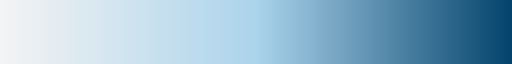

In [271]:
colors=[
    fb.get_color_rgb('山矾'),
    fb.get_color_rgb('碧落'),
    fb.get_color_rgb('蓝采和'),
]
fb.get_cmap_seg(colors)

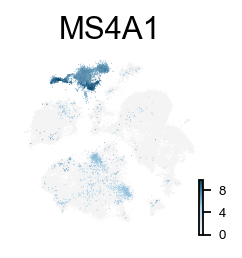

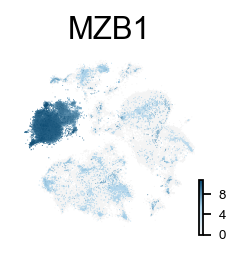

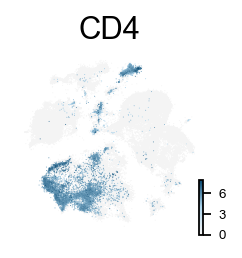

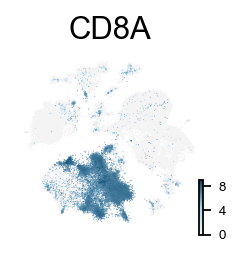

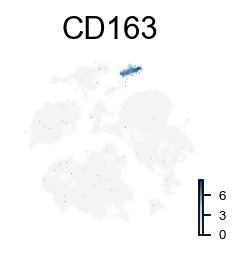

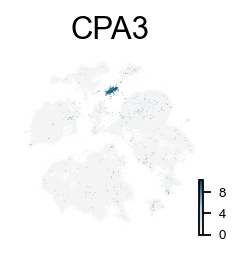

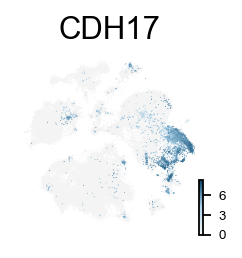

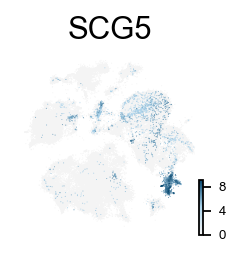

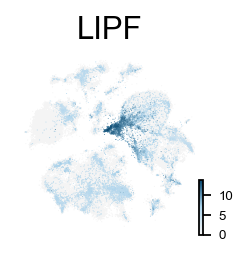

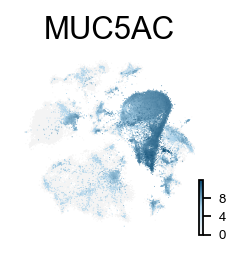

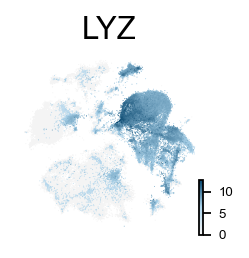

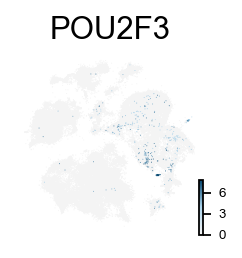

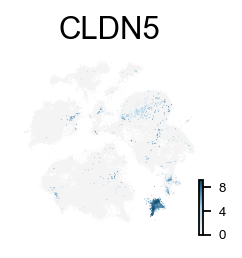

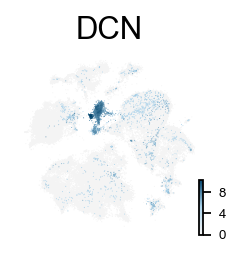

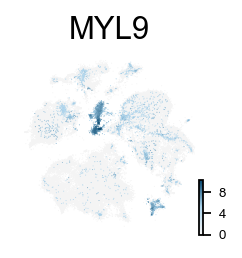

In [273]:
for m in markers.keys():
    gene=markers[m][0]
    fig, ax = plt.subplots(figsize=(1.5,1.5))
    ov.utils.embedding(
        adata,
        basis="X_mde_scVI",
        color=[gene],
        #title='Patient',
        frameon=False,
        cmap=fb.get_cmap_seg(colors),
        ncols=2,
        #palette=colorcet.glasbey_bw_minc_20_maxl_70,
        legend_loc=None,
        legend_fontsize=8,
        ax=ax,
        show=False
        #add_outline=True
        #legend_fontweight='normal'
    )
    fig.savefig(f'figures/exp/umap-{gene}-{m}-1-5.png',dpi=300,bbox_inches='tight')

In [ ]:
adata.write('data/GC_RNA/GC_ANNO.h5ad',compression='gzip')